# TemporalVAE demo notebook with Embryo Beta cells

## Initialize the environment

In [31]:
# -*-coding:utf-8 -*-
import sys
print(f"python version: {sys.version}; {sys.executable}")
import os
print(os.getcwd())
os.chdir("/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE")
sys.path.append(os.getcwd())

python version: 3.10.9 | packaged by conda-forge | (main, Feb  2 2023, 20:20:04) [GCC 11.3.0]; /mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/bin/python
/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE


## Load data

In [32]:
import numpy as np
import pandas as pd
import scanpy as sc

dataset="embryoBeta"

In [33]:
tvae_path = 'https://github.com/StatBiomed/TemporalVAE-reproducibility/raw/refs/heads/main'

Y = pd.read_csv(tvae_path + '/Fig2_TemproalVAE_against_benchmark_methods/' +
                'data_fromPsupertime/embryoBeta_Y.csv', index_col = 0)
Y.head()

,time
bE17.5_1_01,-1
bE17.5_1_02,-1
bE17.5_1_03,-1
bE17.5_1_04,-1
bE17.5_1_05,-1


In [34]:
X = pd.read_csv(tvae_path + '/Fig2_TemproalVAE_against_benchmark_methods/' +
                'data_fromPsupertime/embryoBeta_X.csv', index_col = 0)
X.head()

,bE17.5_1_01,bE17.5_1_02,bE17.5_1_03,bE17.5_1_04,bE17.5_1_05,bE17.5_2_01,bE17.5_2_02,bE17.5_2_03,bE17.5_2_04,bE17.5_2_05,...,bP0_2_30,bP0_2_31,bP9_2_24,bP9_2_25,bP9_2_26,bP9_4_13,bP15_1_21,bP15_1_22,bP60_1_40,bP60_3_30
Symbol,,,,,,,,,,,,,,,,,,,,,
Cdc45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,27.61,0.00,...,0.00,0.00,20.62,0.00,0.00,67.31,53.64,0.0,0.00,0.00
H19,0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.00,0.00,0.85,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
Scml2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,8.42,0.0,0.00,0.00
Narf,18.44,47.67,16.61,6.71,37.55,25.99,15.69,17.02,13.69,0.00,...,38.78,0.00,0.00,6.34,3.59,7.88,0.00,0.0,14.64,30.85
Klf6,0.26,6.11,3.07,0.96,21.38,6.07,20.44,9.39,5.08,7.83,...,22.68,46.41,8.06,9.61,7.48,7.11,14.27,13.6,0.00,14.11


In [35]:
var_df = pd.DataFrame({'GeneName': X.index.values.astype('str')})
var_df.index = var_df['GeneName']

adata = sc.AnnData(X = X.values.transpose(), obs = Y, var = var_df)
adata

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_1374926/2683797749.py:4: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = sc.AnnData(X = X.values.transpose(), obs = Y, var = var_df)


AnnData object with n_obs × n_vars = 575 × 3737
    obs: 'time'
    var: 'GeneName'

In [36]:
adata.obs.groupby(['time'])['time'].count()

time
-1      61
 0      84
 3      88
 9      81
 15     59
 18     71
 60    131
Name: time, dtype: int64

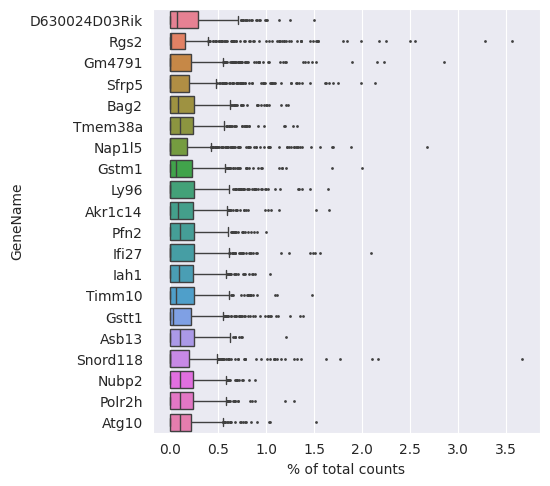

In [37]:
sc.pl.highest_expr_genes(adata, n_top=20)

## Use preprocess method provided by Psupertime

In [38]:
preprocessing_params = {"select_genes": "all", "log": True}
import anndata
from demo.Fig2_TemproalVAE_against_benchmark_methods.pypsupertime import Psupertime

print(f"Input Data: n_genes={adata.n_vars}, n_cells={adata.n_obs}")
# ------------------preprocess adata here
tp = Psupertime(n_jobs=5, n_folds=5,
                preprocessing_params=preprocessing_params
                )  # if for Acinar cell "select_genes": "all"

adata = tp.preprocessing.fit_transform(adata.copy())
del tp


Input Data: n_genes=3737, n_cells=575


In [39]:
adata

AnnData object with n_obs × n_vars = 575 × 3737
    obs: 'time'
    var: 'GeneName', 'n_cells', 'mean', 'std'
    uns: 'log1p'

## Train TemporalVAE with TemporalVAE

In [40]:
method = "tvae"
time_standard_type = "embryoneg5to5"  #
print(f"time standard type: {time_standard_type}")
if not os.path.exists(f'{os.getcwd()}/{method}_results'):
    os.makedirs(f'{os.getcwd()}/{method}_results')

time standard type: embryoneg5to5


In [41]:
import TemporalVAE


## Set model config and logger config

In [42]:
os.getcwd()

'/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE'

In [43]:
# ------- set config and logger ------
train_epoch_num = 60
import yaml
with open("vae_model_configs/supervise_vae_exp2_toyDataset.yaml", 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

In [44]:
import logging
from TemporalVAE.utils.logging_system  import  LogHelper
logger_file = f'{os.getcwd()}/logs/{method}_results/exp2_{dataset}.log'
if not os.path.exists(f'{os.getcwd()}/logs/{method}_results/'):
        os.makedirs(f'{os.getcwd()}/logs/{method}_results/')
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)
print("Finished setting up the logger at: {}.".format(logger_file))

Finished setting up the logger at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta.log.


In [45]:
print(f"Epoch number: {train_epoch_num}")
donor_list = list(np.unique(adata.obs["time"]))
donor_list

Epoch number: 60


[-1, 0, 3, 9, 15, 18, 60]

In [46]:
kFold_test_result_df = pd.DataFrame(columns=['time', 'pseudotime', 'trans_label'])

save_path = _logger.root.handlers[0].baseFilename.replace(".log", "")
save_path

'/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta'

## 1. If you want to do train on all donors and check the umap of latent space.


### Import necessary methods

In [47]:
from TemporalVAE.utils.GPU_manager_pytorch import auto_select_gpu_and_cpu, check_memory
from TemporalVAE.utils.utils_project import trans_time, plot_training_loss_for_tags
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning import seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pathlib import Path

import numpy as np
from TemporalVAE.model_master.experiment_temporalVAE import temporalVAEExperiment
from TemporalVAE.model_master.dataset import  SupervisedVAEDataset_onlyPredict
from TemporalVAE.model_master import vae_models

### Define the save path of results

In [48]:
subFold_save_file_path = "{}/vae_results/all/".format(save_path)
if not os.path.exists(subFold_save_file_path):
    os.makedirs(subFold_save_file_path)
subFold_save_file_path

'/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/vae_results/all/'

### Transpose adata to tensor type for model training

In [49]:
# we need to transpose data to correct its shape
x_sc_train = torch.tensor(adata.X, dtype=torch.get_default_dtype()).t()
print("Set x_sc_train data with shape (gene, cells): {}".format(x_sc_train.shape))
y_time_train = x_sc_train.new_tensor(np.array(adata.obs["time"]).astype(int))
y_time_train

Set x_sc_train data with shape (gene, cells): torch.Size([3737, 575])


tensor([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  3.,  3.,
         3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  

### Normalized the time of each cell.

In [50]:
# for classification model with discrete time cannot use sigmoid and logit time type
y_time_nor_train, label_dic = trans_time(y_time_train, time_standard_type)
print("label dictionary: {}".format(label_dic))
print("Normalize train y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
      .format(time_standard_type, np.unique(y_time_train), y_time_train.shape, np.unique(y_time_nor_train)))
y_time_nor_train

label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 49: 3.197, 60: 5.0, 99: 11.393}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([575]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]


tensor([-5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.83

### Set up structure of VAE model and Start train process

In [51]:
# ------------------------------------------- Set up VAE model and Start train process -------------------------------------------------
print("Start training with epoch: {}. ".format(train_epoch_num))

# if int(config['model_params']['in_channels']) == 0:
config['model_params']['in_channels'] = x_sc_train.shape[0]
tb_logger = TensorBoardLogger(save_dir=subFold_save_file_path,
                              name=config['model_params']['name'], )

# For reproducibility
seed_everything(config['exp_params']['manual_seed'], True)
MyVAEModel = vae_models[config['model_params']['name']](**config['model_params'])
MyVAEModel

2025-07-09 13:22:57,231 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 
2025-07-09 13:22:57,231 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


Start training with epoch: 60. 


SuperviseVanillaVAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=3737, out_features=3737, bias=True)
      (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=3737, out_features=3737, bias=True)
      (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Linear(in_features=3737, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (4): Sequential(
      (0): Linear(in_features=128, out_features=64

### Set up training process parameters

In [52]:
train_data = [[x_sc_train[:, i], y_time_nor_train[i], y_time_train[i]] for i in range(x_sc_train.shape[1])]
from TemporalVAE.model_master.dataset import SupervisedVAEDataset_onlyTrain
data = SupervisedVAEDataset_onlyTrain(train_data=train_data, train_batch_size=len(train_data))

# data.setup("train")
experiment = temporalVAEExperiment(MyVAEModel, config['exp_params'])

lr_monitor = LearningRateMonitor()
check_memory()
device = auto_select_gpu_and_cpu()
print("Auto select run on {}".format(device))

runner = Trainer(logger=tb_logger, log_every_n_steps=1,
                 callbacks=[
                     lr_monitor,
                     ModelCheckpoint(save_top_k=2,
                                     dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
                                     monitor="val_loss",
                                     save_last=True),
                 ],
                 # check_val_every_n_epoch=1, val_check_interval=1,
                 devices=[int(device.split(":")[-1])] if device!="cpu" else "auto",
                 accelerator="gpu" if device!="cpu" else "cpu", max_epochs=train_epoch_num
                 )

Path(f"{tb_logger.log_dir}/Samples").mkdir(exist_ok=True, parents=True)
Path(f"{tb_logger.log_dir}/Reconstructions").mkdir(exist_ok=True, parents=True)

Free Memory Percentage: 48.30%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 32.35GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.848GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 18.106GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.848GB
Auto select run on cuda:1


2025-07-09 13:22:58,906 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-09 13:22:58,906 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-09 13:22:58,907 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-09 13:22:58,907 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-09 13:22:58,909 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-09 13:22:58,909 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-09 13:22:58,910 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2025-07-09 13:22:58,910 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 


### Starting training.

In [53]:

print(f"======= Training {config['model_params']['name']} =======")
runner.fit(experiment, data)

# test the model
data_predict = SupervisedVAEDataset_onlyPredict(predict_data=train_data, predict_batch_size=len(train_data))
train_result = runner.predict(experiment, data_predict)
train_clf_result, train_latent_mu_result, train_latent_log_var_result = train_result[0][0], train_result[0][1], \
    train_result[0][2]

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
2025-07-09 13:22:59,073 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-09 13:22:59,073 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more deta

======= Training SuperviseVanillaVAE =======


2025-07-09 13:22:59,273 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-09 13:22:59,273 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-09 13:22:59,279 INFO - pytorch_lightning.callbacks.model_summary - 
  | Name  | Type                | Params
----------------------------------------------
0 | model | SuperviseVanillaVAE | 44.0 M
----------------------------------------------
44.0 M    Trainable params
0         Non-trainable params
44.0 M    Total params
175.829   Total estimated model params size (MB) 
2025-07-09 13:22:59,279 INFO - pytorch_lightning.callbacks.model_summary - 
  | Name  | Type                | Params
----------------------------------------------
0 | model | SuperviseVanillaVAE | 44.0 M
----------------------------------------------
44.0 M    Trainable params
0         Non-trainable params
44.0 M    Total params
175.829   Total estimated model params size (MB) 
/m

Training: 0it [00:00, ?it/s]

Epoch train loss: {'train_loss_step': tensor(1.3867, device='cuda:1'), 'train_Reconstruction_loss_step': tensor(1.3852, device='cuda:1'), 'train_KLD_step': tensor(-6.0102, device='cuda:1'), 'train_loss_epoch': tensor(1.3867, device='cuda:1'), 'train_Reconstruction_loss_epoch': tensor(1.3852, device='cuda:1'), 'train_KLD_epoch': tensor(-6.0102, device='cuda:1')}
Epoch train loss: {'train_loss_step': tensor(1.3206, device='cuda:1'), 'train_Reconstruction_loss_step': tensor(1.3188, device='cuda:1'), 'train_KLD_step': tensor(-7.3802, device='cuda:1'), 'train_loss_epoch': tensor(1.3206, device='cuda:1'), 'train_Reconstruction_loss_epoch': tensor(1.3188, device='cuda:1'), 'train_KLD_epoch': tensor(-7.3802, device='cuda:1')}
Epoch train loss: {'train_loss_step': tensor(1.0911, device='cuda:1'), 'train_Reconstruction_loss_step': tensor(1.0858, device='cuda:1'), 'train_KLD_step': tensor(-21.4729, device='cuda:1'), 'train_loss_epoch': tensor(1.0911, device='cuda:1'), 'train_Reconstruction_loss_e

2025-07-09 13:28:25,135 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=60` reached. 
2025-07-09 13:28:25,135 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=60` reached. 
2025-07-09 13:28:26,224 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-09 13:28:26,224 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://py

Predicting: 0it [00:00, ?it/s]

### Clear cache

In [54]:
del runner
del experiment
# 清除CUDA缓存
torch.cuda.empty_cache()

In [55]:
MyVAEModel

SuperviseVanillaVAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=3737, out_features=3737, bias=True)
      (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=3737, out_features=3737, bias=True)
      (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Linear(in_features=3737, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (4): Sequential(
      (0): Linear(in_features=128, out_features=64

In [56]:
adata

AnnData object with n_obs × n_vars = 575 × 3737
    obs: 'time'
    var: 'GeneName', 'n_cells', 'mean', 'std'
    uns: 'log1p'

... storing 'time_group' as categorical


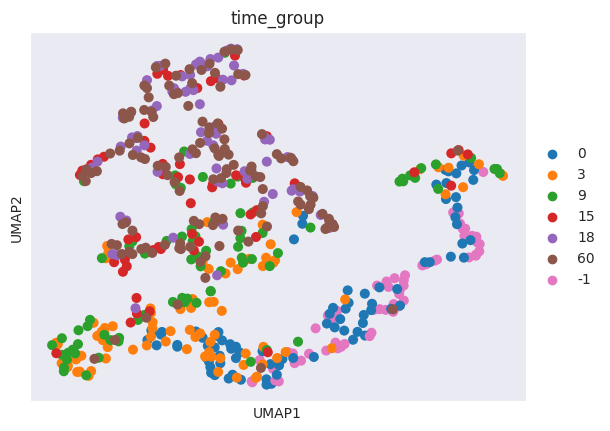

In [57]:
#train_clf_result, train_latent_mu_result
adata1 = adata.copy()
adata1.obsm['X_pca'] = train_latent_mu_result.cpu().data.numpy()
adata1.obs["time_group"] = adata1.obs['time'].values.astype('str')

sc.pp.neighbors(adata1, n_neighbors=5, n_pcs=10,random_state=0)
sc.tl.umap(adata1,random_state=0)

sc.pl.umap(adata1, color=["time_group"])

## If you want to do multiple loop calculations: test on one donor and train on other donors.


## Define a function: test on one donor and train on other donors.

In [58]:
# def process_fold_toyDataset(fold, donor_list, adata, time_standard_type, config, save_path, train_epoch_num):
#     from TemporalVAE.utils.GPU_manager_pytorch import auto_select_gpu_and_cpu, check_memory
#     from TemporalVAE.utils.utils_project import trans_time, plot_training_loss_for_tags
#     import torch
#     from pytorch_lightning import Trainer
#     from pytorch_lightning.loggers import TensorBoardLogger
#     from pytorch_lightning import seed_everything
#     from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
#     from pathlib import Path
#
#     import numpy as np
#     from TemporalVAE.model_master.experiment_temporalVAE import temporalVAEExperiment
#     from TemporalVAE.model_master.dataset import SupervisedVAEDataset, SupervisedVAEDataset_onlyPredict
#     from TemporalVAE.model_master import vae_models
#     # _logger = logging.getLogger(__name__)
#     # time.sleep(random.randint(5, 20))
#     print("the {}/{} fold train, use donor-{} as test set".format(fold + 1, len(donor_list), donor_list[fold]))
#
#     train_adata = adata[adata.obs["time"] != donor_list[fold]].copy()
#     test_adata = adata[adata.obs["time"] == donor_list[fold]].copy()
#     # move one cell from test to train to occupy the test time
#     one_test_cell = test_adata[:5].copy()
#     test_adata = test_adata[5:].copy()
#     train_adata = anndata.concat([train_adata.copy(), one_test_cell.copy()], axis=0)
#
#     # ----------------------------------------split Train and Test dataset-----------------------------------------------------
#     print("the {}/{} fold train, use donor-{} as test set".format(fold + 1, len(donor_list), donor_list[fold]))
#     subFold_save_file_path = "{}/vae_results/{}/".format(save_path,
#                                                          donor_list[fold])
#
#     if not os.path.exists(subFold_save_file_path):
#         os.makedirs(subFold_save_file_path)
#     # we need to transpose data to correct its shape
#     x_sc_train = torch.tensor(train_adata.X, dtype=torch.get_default_dtype()).t()
#     x_sc_test = torch.tensor(test_adata.X, dtype=torch.get_default_dtype()).t()
#     print("Set x_sc_train data with shape (gene, cells): {}".format(x_sc_train.shape))
#     print("Set x_sc_test data with shape (gene, cells): {}".format(x_sc_test.shape))
#
#     # trans y_time
#
#     y_time_train = x_sc_train.new_tensor(np.array(train_adata.obs["time"]).astype(int))
#     y_time_test = x_sc_test.new_tensor(np.array(test_adata.obs["time"]).astype(int))
#
#     # for classification model with discrete time cannot use sigmoid and logit time type
#     y_time_nor_train, label_dic = trans_time(y_time_train, time_standard_type, capture_time_other=y_time_test)
#     y_time_nor_test, label_dic = trans_time(y_time_test, time_standard_type, label_dic_train=label_dic)
#     print("label dictionary: {}".format(label_dic))
#     print("Normalize train y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
#           .format(time_standard_type, np.unique(y_time_train), y_time_train.shape, np.unique(y_time_nor_train)))
#     print("Normalize test y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
#           .format(time_standard_type, np.unique(y_time_test), y_time_test.shape, np.unique(y_time_nor_test)))
#
#     # ------------------------------------------- Set up VAE model and Start train process -------------------------------------------------
#     print("Start training with epoch: {}. ".format(train_epoch_num))
#
#     # if int(config['model_params']['in_channels']) == 0:
#     config['model_params']['in_channels'] = x_sc_train.shape[0]
#     tb_logger = TensorBoardLogger(save_dir=subFold_save_file_path,
#                                   name=config['model_params']['name'], )
#
#     # For reproducibility
#     seed_everything(config['exp_params']['manual_seed'], True)
#
#     MyVAEModel = vae_models[config['model_params']['name']](**config['model_params'])
#
#     ## print parameters of model
#     # for name, param in MyVAEModel.named_parameters():
#     #     print(name, param)
#     train_data = [[x_sc_train[:, i], y_time_nor_train[i], y_time_train[i]] for i in range(x_sc_train.shape[1])]
#     test_data = [[x_sc_test[:, i], y_time_nor_test[i], y_time_test[i]] for i in range(x_sc_test.shape[1])]
#     print("don't set batch")
#     data = SupervisedVAEDataset(train_data=train_data, val_data=test_data, test_data=test_data, predict_data=test_data,
#                                 train_batch_size=len(train_data), val_batch_size=len(test_data),
#                                 test_batch_size=len(test_data), predict_batch_size=len(test_data),
#                                 label_dic=label_dic)
#
#     # data.setup("train")
#     experiment = temporalVAEExperiment(MyVAEModel, config['exp_params'])
#
#     # 创建一个 LearningRateMonitor 回调实例
#     lr_monitor = LearningRateMonitor()
#     # 2023-09-07 20:34:25 add check memory
#     check_memory()
#     device = auto_select_gpu_and_cpu()
#     print("Auto select run on {}".format(device))
#
#     runner = Trainer(logger=tb_logger, log_every_n_steps=1,
#                      callbacks=[
#                          lr_monitor,
#                          ModelCheckpoint(save_top_k=2,
#                                          dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
#                                          monitor="val_loss",
#                                          save_last=True),
#                      ],
#                      # check_val_every_n_epoch=1, val_check_interval=1,
#                      devices=[int(device.split(":")[-1])],
#                      accelerator="gpu", max_epochs=train_epoch_num
#                      )
#
#     Path(f"{tb_logger.log_dir}/Samples").mkdir(exist_ok=True, parents=True)
#     Path(f"{tb_logger.log_dir}/Reconstructions").mkdir(exist_ok=True, parents=True)
#
#     print(f"======= Training {config['model_params']['name']} =======")
#     runner.fit(experiment, data)
#
#     # test the model
#     print("this epoch final, on test data:{}".format(runner.test(experiment, data)))
#     # predict on train data
#     data_predict = SupervisedVAEDataset_onlyPredict(predict_data=train_data, predict_batch_size=len(train_data))
#     train_result = runner.predict(experiment, data_predict)
#     train_clf_result, train_latent_mu_result, train_latent_log_var_result = train_result[0][0], train_result[0][1], \
#         train_result[0][2]
#     # predict on test data
#     data_test = SupervisedVAEDataset_onlyPredict(predict_data=test_data, predict_batch_size=len(test_data))
#     test_result = runner.predict(experiment, data_test)
#     test_clf_result, test_latent_mu_result, test_latent_log_var_result = test_result[0][0], test_result[0][1], \
#         test_result[0][2]
#     if (np.isnan(np.squeeze(test_clf_result)).any()):
#         print("The Array contain NaN values")
#     else:
#         print("The Array does not contain NaN values")
#     print("predicted time of test donor is continuous.")
#
#     _result_df = pd.DataFrame({'time': donor_list[fold],  # First column with a constant value of 1
#                                'pseudotime': np.squeeze(test_clf_result, axis=1)})
#
#     # _result_df['pseudotime'] = _result_df['pseudotime_normalized'].apply(denormalize, args=(min(label_dic.keys()), max(label_dic.keys()), min(label_dic.values()), max(label_dic.values())))
#     _result_df["trans_label"] = _result_df["time"].map(label_dic)
#     print("Plot training loss line for check.")
#
#     from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
#     tags = EventAccumulator(tb_logger.log_dir).Reload().Tags()['scalars']
#     print("All tags in logger: {}".format(tags))
#     # Retrieve and print the metric results
#     plot_tag_list = list(set(["train_clf_loss_epoch", "val_clf_loss", "test_clf_loss_epoch"]) & set(tags))
#     print(f"plot tags {plot_tag_list}")
#     plot_training_loss_for_tags(tb_logger, plot_tag_list, special_str=donor_list[fold], title=donor_list[fold])
#
#     # ---------------------------------------------- save sub model parameters for check  --------------------------------------------------
#     print("encoder and decoder structure: {}".format({"encoder": MyVAEModel.encoder, "decoder": MyVAEModel.decoder}))
#     print("clf-decoder structure: {}".format({"encoder": MyVAEModel.clf_decoder}))
#     torch.save(MyVAEModel, tb_logger.root_dir + "/version_" + str(tb_logger.version) + '/model.pth')
#     print("detail information about structure save at： {}".format(
#         tb_logger.root_dir + "/version_" + str(tb_logger.version) + '/model.pth'))
#
#
#     del runner
#     del experiment
#     # 清除CUDA缓存
#     torch.cuda.empty_cache()
#     return _result_df,MyVAEModel,test_latent_mu_result

In [59]:
from TemporalVAE.model_master.dataset import SupervisedVAEDataset
def process_fold_toyDataset(fold, donor_list, adata, time_standard_type, config, save_path, train_epoch_num):
    # _logger = logging.getLogger(__name__)
    # time.sleep(random.randint(5, 20))
    print("the {}/{} fold train, use donor-{} as test set".format(fold + 1, len(donor_list), donor_list[fold]))

    train_adata = adata[adata.obs["time"] != donor_list[fold]].copy()
    test_adata = adata[adata.obs["time"] == donor_list[fold]].copy()
    # move one cell from test to train to occupy the test time
    one_test_cell = test_adata[:5].copy()
    test_adata = test_adata[5:].copy()
    train_adata = anndata.concat([train_adata.copy(), one_test_cell.copy()], axis=0)

    # ----------------------------------------split Train and Test dataset-----------------------------------------------------
    print("the {}/{} fold train, use donor-{} as test set".format(fold + 1, len(donor_list), donor_list[fold]))
    subFold_save_file_path = f"{save_path}/temporalVAE_results/{donor_list[fold]}/"

    if not os.path.exists(subFold_save_file_path):
        os.makedirs(subFold_save_file_path)
    # we need to transpose data to correct its shape
    x_sc_train = torch.tensor(train_adata.X, dtype=torch.get_default_dtype()).t()
    x_sc_test = torch.tensor(test_adata.X, dtype=torch.get_default_dtype()).t()
    print("Set x_sc_train data with shape (gene, cells): {}".format(x_sc_train.shape))
    print("Set x_sc_test data with shape (gene, cells): {}".format(x_sc_test.shape))

    # trans y_time

    y_time_train = x_sc_train.new_tensor(np.array(train_adata.obs["time"]).astype(int))
    y_time_test = x_sc_test.new_tensor(np.array(test_adata.obs["time"]).astype(int))

    # for classification model with discrete time cannot use sigmoid and logit time type
    y_time_nor_train, label_dic = trans_time(y_time_train, time_standard_type, capture_time_other=y_time_test)
    y_time_nor_test, label_dic = trans_time(y_time_test, time_standard_type, label_dic_train=label_dic)
    print("label dictionary: {}".format(label_dic))
    print("Normalize train y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
          .format(time_standard_type, np.unique(y_time_train), y_time_train.shape, np.unique(y_time_nor_train)))
    print("Normalize test y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
          .format(time_standard_type, np.unique(y_time_test), y_time_test.shape, np.unique(y_time_nor_test)))

    # ------------------------------------------- Set up temporalVAE model and Start train process -------------------------------------------------
    print("Start training with epoch: {}. ".format(train_epoch_num))

    # if int(config['model_params']['in_channels']) == 0:
    config['model_params']['in_channels'] = x_sc_train.shape[0]
    tb_logger = TensorBoardLogger(save_dir=subFold_save_file_path,
                                  name=config['model_params']['name'], )

    # For reproducibility
    seed_everything(config['exp_params']['manual_seed'], True)

    MyVAEModel = vae_models[config['model_params']['name']](**config['model_params'])

    ## print parameters of model
    # for name, param in MyVAEModel.named_parameters():
    #     print(name, param)
    train_data = [[x_sc_train[:, i], y_time_nor_train[i], y_time_train[i]] for i in range(x_sc_train.shape[1])]
    test_data = [[x_sc_test[:, i], y_time_nor_test[i], y_time_test[i]] for i in range(x_sc_test.shape[1])]
    print("don't set batch")
    data = SupervisedVAEDataset(train_data=train_data, val_data=test_data, test_data=test_data, predict_data=test_data,
                                train_batch_size=len(train_data), val_batch_size=len(test_data),
                                test_batch_size=len(test_data), predict_batch_size=len(test_data),
                                label_dic=label_dic)

    # data.setup("train")
    experiment = temporalVAEExperiment(MyVAEModel, config['exp_params'])

    # 创建一个 LearningRateMonitor 回调实例
    lr_monitor = LearningRateMonitor()
    # 2023-09-07 20:34:25 add check memory
    check_memory()
    device = auto_select_gpu_and_cpu()
    print("Auto select run on {}".format(device))

    runner = Trainer(logger=tb_logger, log_every_n_steps=1,
                     callbacks=[
                         lr_monitor,
                         ModelCheckpoint(save_top_k=2,
                                         dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
                                         monitor="val_loss",
                                         save_last=True),
                     ],
                     # check_val_every_n_epoch=1, val_check_interval=1,
                     devices=[int(device.split(":")[-1])],
                     accelerator="gpu", max_epochs=train_epoch_num
                     )

    Path(f"{tb_logger.log_dir}/Samples").mkdir(exist_ok=True, parents=True)
    Path(f"{tb_logger.log_dir}/Reconstructions").mkdir(exist_ok=True, parents=True)

    print(f"======= Training {config['model_params']['name']} =======")
    runner.fit(experiment, data)

    # test the model
    print("this epoch final, on test data:{}".format(runner.test(experiment, data)))
    # predict on train data
    data_predict = SupervisedVAEDataset_onlyPredict(predict_data=train_data, predict_batch_size=len(train_data))
    train_result = runner.predict(experiment, data_predict)
    train_clf_result, train_latent_mu_result, train_latent_log_var_result = train_result[0][0], train_result[0][1], \
        train_result[0][2]
    # predict on test data
    data_test = SupervisedVAEDataset_onlyPredict(predict_data=test_data, predict_batch_size=len(test_data))
    test_result = runner.predict(experiment, data_test)
    test_clf_result, test_latent_mu_result, test_latent_log_var_result = test_result[0][0], test_result[0][1], \
        test_result[0][2]
    if (np.isnan(np.squeeze(test_clf_result)).any()):
        print("The Array contain NaN values")
    else:
        print("The Array does not contain NaN values")
    print("predicted time of test donor is continuous.")

    _result_df = pd.DataFrame({'time': donor_list[fold],  # First column with a constant value of 1
                               'pseudotime': np.squeeze(test_clf_result, axis=1)})
    # _result_df['pseudotime'] = _result_df['pseudotime_normalized'].apply(denormalize, args=(min(label_dic.keys()), max(label_dic.keys()), min(label_dic.values()), max(label_dic.values())))
    _result_df["trans_label"] = _result_df["time"].map(label_dic)
    print("Plot training loss line for check.")

    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    tags = EventAccumulator(tb_logger.log_dir).Reload().Tags()['scalars']
    print("All tags in logger: {}".format(tags))
    # Retrieve and print the metric results
    plot_tag_list = list(set(["train_clf_loss_epoch", "val_clf_loss", "test_clf_loss_epoch"]) & set(tags))
    print(f"plot tags {plot_tag_list}")
    plot_training_loss_for_tags(tb_logger, plot_tag_list, special_str=donor_list[fold], title=donor_list[fold])

    # ---------------------------------------------- save sub model parameters for check  --------------------------------------------------
    print("encoder and decoder structure: {}".format({"encoder": MyVAEModel.encoder, "decoder": MyVAEModel.decoder}))
    print("clf-decoder structure: {}".format({"encoder": MyVAEModel.clf_decoder}))
    torch.save(MyVAEModel, tb_logger.root_dir + "/version_" + str(tb_logger.version) + '/model.pth')
    print("detail information about structure save at： {}".format(
        tb_logger.root_dir + "/version_" + str(tb_logger.version) + '/model.pth'))

    del MyVAEModel
    del runner
    del experiment
    # 清除CUDA缓存
    torch.cuda.empty_cache()
    return _result_df

In [60]:
for fold in range(len(donor_list)):
    _result_df,_,_ = process_fold_toyDataset(fold, donor_list, adata, time_standard_type, config, save_path, train_epoch_num)

    kFold_test_result_df = pd.concat([kFold_test_result_df, _result_df], axis=0)
print("k-fold test final result:")
kFold_test_result_df

2025-07-09 13:28:32,139 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 
2025-07-09 13:28:32,139 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


the 1/7 fold train, use donor--1 as test set
the 1/7 fold train, use donor--1 as test set
Set x_sc_train data with shape (gene, cells): torch.Size([3737, 519])
Set x_sc_test data with shape (gene, cells): torch.Size([3737, 56])
label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 49: 3.197, 60: 5.0, 99: 11.393}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([519]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]
Normalize test y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.], shape: torch.Size([56]), 
detail: [-5.]
Start training with epoch: 60. 


2025-07-09 13:28:33,754 WARNING - pytorch_lightning.loggers.tensorboard - Missing logger folder: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/-1/SuperviseVanillaVAE 
2025-07-09 13:28:33,754 WARNING - pytorch_lightning.loggers.tensorboard - Missing logger folder: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/-1/SuperviseVanillaVAE 
2025-07-09 13:28:33,937 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-09 13:28:33,937 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-09 13:28:33,938 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-09 13:28:33,938 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-09 13:28:33,940 INFO - pytorch_lightning.utilities.rank_zero - IPU avail

don't set batch
Free Memory Percentage: 48.61%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 32.35GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.848GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 18.106GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.848GB
Auto select run on cuda:1
======= Training SuperviseVanillaVAE =======


2025-07-09 13:28:33,982 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-09 13:28:34,982 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-09 13:28:34,263 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-09 13:28

...

Predicting: 0it [00:00, ?it/s]

2025-07-09 13:34:02,192 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-09 13:34:02,192 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-09 13:34:02,253 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-09 13:34

Predicting: 0it [00:00, ?it/s]

The Array does not contain NaN values
predicted time of test donor is continuous.


AxisError: axis 1 is out of bounds for array of dimension 1

spearman correlation score: 0.932788291869457, p-value: 1.3573877555223933e-240.
kendalltau correlation score: 0.8013037001251352,p-value: 1.28783073906612e-148.
test result save at /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/tvae_results/embryoBeta_tvae_result.csv


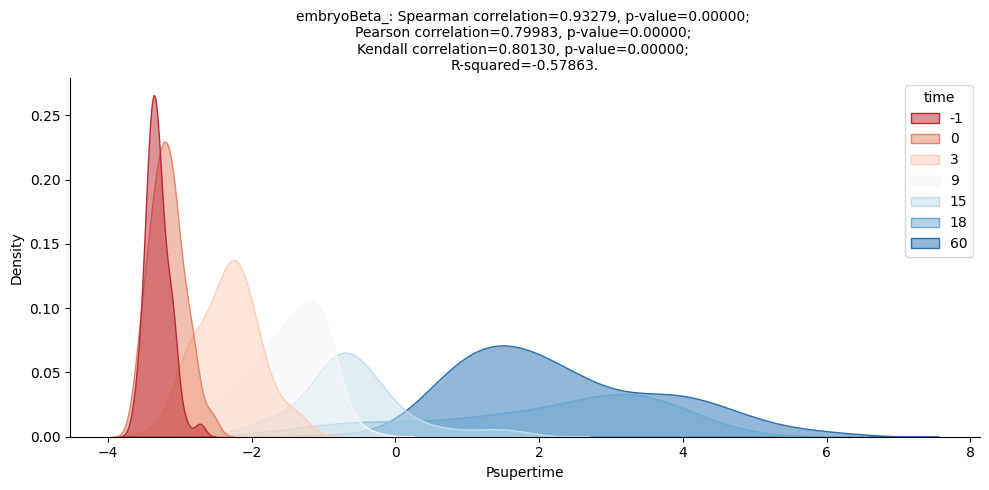

figure save at /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/tvae_results//embryoBeta__labelsOverPsupertime.png
figure save at /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/tvae_results//embryoBeta_labelsOverPsupertime.png


In [20]:
def corr(x1, x2):
    from scipy.stats import spearmanr, kendalltau
    sp_correlation, sp_p_value = spearmanr(x1, x2)
    ke_correlation, ke_p_value = kendalltau(x1, x2)
    print(f"spearman correlation score: {sp_correlation}, p-value: {sp_p_value}.")
    print(f"kendalltau correlation score: {ke_correlation},p-value: {ke_p_value}.")

corr(kFold_test_result_df["time"], kFold_test_result_df["pseudotime"])
kFold_test_result_df.to_csv(f'{os.getcwd()}/{method}_results/{dataset}_{method}_result.csv', index=True)
print(f"test result save at {os.getcwd()}/{method}_results/{dataset}_{method}_result.csv")

# f = tp.plot_grid_search(title="Grid Search")
# f.savefig(f"{os.getcwd()}/psupertime_results/gridSearch.png")
# f = tp.plot_model_perf((adata.X, adata.obs.time), figsize=(6, 5))
# f.savefig(f"{os.getcwd()}/psupertime_results/modelPred.png")
# f = tp.plot_identified_gene_coefficients(adata, n_top=20)
# f.savefig(f"{os.getcwd()}/psupertime_results/geneCoff.png")
from TemporalVAE.utils.utils_plot import plot_psupertime_density
save_path = f"{os.getcwd()}/{method}_results/"
plot_psupertime_density(kFold_test_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=f"{dataset}_")
print(f"figure save at {save_path}/{dataset}_labelsOverPsupertime.png")